In [119]:
import numpy as np
import yfinance as yf
from utils import plot_returns

In [120]:
# Download S&P 500 front month futures data
prices = yf.download("ES=F", start="2015-01-01")["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed


In [121]:
# Calculate daily logarithmic returns
log_returns = np.log(prices).diff().dropna()

In [122]:
# Annualized returns and volatility
trading_days = 252
annualized_return = (
    log_returns.mean() * trading_days
)  # mean daily return scaled to annual
annualized_vol = log_returns.std() * np.sqrt(trading_days)

In [123]:
print(f"Annualized Return: {annualized_return * 100:.2f}%")
print(f"Annualized Volatility: {annualized_vol * 100:.2f}%")

Annualized Return: 11.47%
Annualized Volatility: 17.86%


In [124]:
# Download the 3-month Treasury bill rate as the risk-free rate
sp500_start_date = str(prices.index[0])[:10]
risk_free_rates = yf.download("^IRX", start=sp500_start_date)["Close"].squeeze()
avg_risk_free_rate = risk_free_rates.mean() / 100

[*********************100%***********************]  1 of 1 completed


In [125]:
risk_free_rates.head()

Date
2015-01-02    0.015
2015-01-05    0.003
2015-01-06    0.020
2015-01-07    0.020
2015-01-08    0.018
Name: ^IRX, dtype: float64

In [126]:
# Calculate the Sharpe Ratio
sharpe_ratio = (annualized_return - avg_risk_free_rate) / annualized_vol
print(f"sharpe_ratio: {np.round(sharpe_ratio, 2)}")

sharpe_ratio: 0.53


In [127]:
# Calculate the Sortino Ratio
daily_risk_free_rate = avg_risk_free_rate / trading_days
excess_returns = log_returns - daily_risk_free_rate  # daily excess returns (Series)
downside_returns = excess_returns.clip(upper=0)  # keep only negative excess returns
downside_vol = downside_returns.std() * np.sqrt(
    trading_days
)  # annualized downside deviation
sortino_ratio = (annualized_return - avg_risk_free_rate) / downside_vol
print(f"sortino_ratio: {np.round(sortino_ratio, 2)}")

sortino_ratio: 0.8


In [128]:
# Calculate the Calmar Ratio
cum_returns = np.exp(log_returns.cumsum())
running_max = cum_returns.cummax()  # peak seen up to each date
drawdowns = (cum_returns - running_max) / running_max  # always <= 0
max_drawdown = drawdowns.min()  # most negative value
calmar_ratio = annualized_return / abs(max_drawdown)
print(f"max_drawdown: {np.round(max_drawdown * 100, 2)}%")
print(f"calmar_ratio: {np.round(calmar_ratio, 2)}")

max_drawdown: -34.45%
calmar_ratio: 0.33


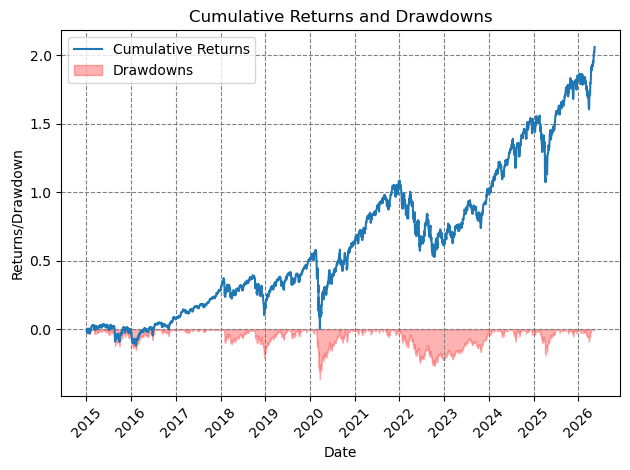

In [129]:
plot_returns(log_returns)